In [1]:
# Import the required libraries

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from collections import Counter
import folium
from folium.plugins import MarkerCluster
import glob
import os
import bz2
from tqdm import tqdm
import re
from datetime import datetime

# Configurações
ACCIDENT_DATA_FILE = "data/crashes_data/plane_crash_data.csv"
COORDINATES_FILE = "data/crashes_data/coordinates_cache.csv"

# Preprocessing Airports

In [2]:
# Load the CSV file into a pandas DataFrame
airports_df = pd.read_csv('data/flights_data/airports.csv')

print("First 5 rows of airports data:")
print(airports_df.head())

First 5 rows of airports data:
  iata               airport              city state country        lat  \
0  00M              Thigpen        Bay Springs    MS     USA  31.953765   
1  00R  Livingston Municipal        Livingston    TX     USA  30.685861   
2  00V           Meadow Lake  Colorado Springs    CO     USA  38.945749   
3  01G          Perry-Warsaw             Perry    NY     USA  42.741347   
4  01J      Hilliard Airpark          Hilliard    FL     USA  30.688012   

         long  
0  -89.234505  
1  -95.017928  
2 -104.569893  
3  -78.052081  
4  -81.905944  


# Preprocessing Carriers

In [3]:
# Load the carriers CSV file into a DataFrame
carriers_df = pd.read_csv('data/flights_data/carriers.csv')

# Display the first few rows to verify the data was loaded correctly
print("First 5 rows of carriers data:")
print(carriers_df.head())

# Display basic DataFrame information
print(f"\nTotal number of carriers: {len(carriers_df)}")
print(f"\nDataFrame columns: {carriers_df.columns.tolist()}")

First 5 rows of carriers data:
  Code                    Description
0  02Q                  Titan Airways
1  04Q             Tradewind Aviation
2  05Q            Comlux Aviation, AG
3  06Q  Master Top Linhas Aereas Ltd.
4  07Q            Flair Airlines Ltd.

Total number of carriers: 1491

DataFrame columns: ['Code', 'Description']


# Preprocessing Plane data dataset

In [4]:
# Load the plane data CSV file into a DataFrame
plane_df = pd.read_csv('data/flights_data/plane-data.csv')

# Display the first few rows to verify the data was loaded correctly
print("First 5 rows of aircraft data:")
print(plane_df.head())

# Display basic DataFrame information
print(f"\nTotal number of aircraft: {len(plane_df)}")
print(f"\nDataFrame columns: {plane_df.columns.tolist()}")

# Check for missing values
print(f"\nMissing values in each column:")
print(plane_df.isnull().sum())

# Display basic statistics for the dataset
print("\nBasic statistics for numeric columns:")
print(plane_df.describe())

First 5 rows of aircraft data:
  tailnum type manufacturer issue_date model status aircraft_type engine_type  \
0  N050AA  NaN          NaN        NaN   NaN    NaN           NaN         NaN   
1  N051AA  NaN          NaN        NaN   NaN    NaN           NaN         NaN   
2  N052AA  NaN          NaN        NaN   NaN    NaN           NaN         NaN   
3  N054AA  NaN          NaN        NaN   NaN    NaN           NaN         NaN   
4  N055AA  NaN          NaN        NaN   NaN    NaN           NaN         NaN   

   year  
0   NaN  
1   NaN  
2   NaN  
3   NaN  
4   NaN  

Total number of aircraft: 5029

DataFrame columns: ['tailnum', 'type', 'manufacturer', 'issue_date', 'model', 'status', 'aircraft_type', 'engine_type', 'year']

Missing values in each column:
tailnum            0
type             549
manufacturer     549
issue_date       550
model            549
status           549
aircraft_type    549
engine_type      552
year             694
dtype: int64

Basic statistics for numer

# Preprocessing Flights

In [5]:
def process_flight_data(start_year=1987, end_year=2008, sample_frac=None, verbose=True):
    """
    Process flight data from compressed bz2 files.
    
    Parameters:
    -----------
    start_year : int, optional
        First year to process (default: 1987)
    end_year : int, optional
        Last year to process (default: 2008)
    sample_frac : float, optional
        If provided, sample this fraction of data from each file (default: None)
    verbose : bool, optional
        Whether to print processing information (default: True)
        
    Returns:
    --------
    dict
        Dictionary with years as keys and DataFrames or stats as values
    """
    # Find all bz2 files in the data directory
    file_pattern = os.path.join('data', '*.csv.bz2')
    all_files = glob.glob(file_pattern)
    
    # Filter files by year range
    files_to_process = [f for f in all_files if start_year <= int(os.path.basename(f).split('.')[0]) <= end_year]
    
    if verbose:
        print(f"Found {len(files_to_process)} files to process between {start_year} and {end_year}")
    
    # Dictionary to store results
    results = {}
    
    # Process each file
    for file_path in tqdm(files_to_process, desc="Processing flight data files"):
        year = int(os.path.basename(file_path).split('.')[0])
        
        if verbose:
            print(f"\nProcessing data for year {year}...")
        
        # Read bz2 file into DataFrame
        try:
            with bz2.open(file_path, 'rt') as file:
                if sample_frac:
                    # Use sampling for large files
                    df = pd.read_csv(file, sample=sample_frac)
                else:
                    # Read the entire file
                    df = pd.read_csv(file)
            
            # Store DataFrame in results
            results[year] = df
            
            if verbose:
                print(f"  - Loaded {len(df)} records")
                print(f"  - Memory usage: {df.memory_usage().sum() / (1024**2):.2f} MB")
        
        except Exception as e:
            print(f"Error processing file for year {year}: {str(e)}")
    
    return results

# Example usage
full_data  = process_flight_data()

Found 0 files to process between 1987 and 2008


Processing flight data files: 0it [00:00, ?it/s]


## Process all flight routes count 

In [6]:
# Function to count all flight routes without any filtering
def count_all_flight_routes(flight_data, airports_df):
    """
    Count all flight routes from flight data and merge with airport information.
    
    Parameters:
    -----------
    flight_data : dict
        Dictionary with years as keys and flight DataFrames as values
    airports_df : DataFrame
        DataFrame containing airport information
        
    Returns:
    --------
    DataFrame
        Complete DataFrame with all route counts and details
    """
    print("Counting all flights by route...")
    
    # Create empty DataFrame to store route counts
    all_routes_count = pd.DataFrame()
    
    # Stats collectors for summary
    total_records = 0
    total_missing_origin = 0
    total_missing_dest = 0
    total_cancelled = 0
    
    # Process each year
    for year, df in tqdm(flight_data.items(), desc="Processing all years"):
        # Data quality check before filtering
        print(f"\n=== Data quality check for year {year} ===")
        print(f"Total rows for year {year}: {len(df):,}")
        print(f"Rows with missing Origin: {df['Origin'].isna().sum():,}")
        print(f"Rows with missing Dest: {df['Dest'].isna().sum():,}")
        print(f"Cancelled flights: {df['Cancelled'].sum():,}")
        
        # Update totals for final summary
        total_records += len(df)
        total_missing_origin += df['Origin'].isna().sum()
        total_missing_dest += df['Dest'].isna().sum()
        total_cancelled += df['Cancelled'].sum()
        
        # Skip cancelled flights
        valid_flights = df[df['Cancelled'] == 0]
        
        # Report on discarded rows
        discarded = len(df) - len(valid_flights)
        print(f"Discarded {discarded:,} rows ({discarded/len(df)*100:.2f}%)")
        
        # Continue with the existing processing...
        # Use FlightNum or any other column instead of Origin for counting
        year_routes = valid_flights.groupby(['Origin', 'Dest']).agg({
            'Distance': 'mean',    # Mean distance for this route
            'FlightNum': 'count'   # Count of flights using FlightNum
        }).reset_index()

        year_routes.columns = ['Origin', 'Dest', 'Distance_km', 'Count']
        year_routes['Year'] = year
        
        # Append to main DataFrame
        all_routes_count = pd.concat([all_routes_count, year_routes])
    
    print("\n=== FINAL DATA QUALITY SUMMARY ===")
    print(f"Total records processed: {total_records:,}")
    print(f"Total records with missing Origin: {total_missing_origin:,} ({total_missing_origin/total_records*100:.2f}%)")
    print(f"Total records with missing Destination: {total_missing_dest:,} ({total_missing_dest/total_records*100:.2f}%)")
    print(f"Total cancelled flights: {total_cancelled:,} ({total_cancelled/total_records*100:.2f}%)")
    print(f"Total records used in route analysis: {total_records - total_cancelled:,} ({(total_records - total_cancelled)/total_records*100:.2f}%)")
    
    # Aggregate counts by route (across all years)
    # Include both Count and Distance_km in the final aggregation
    route_totals = all_routes_count.groupby(['Origin', 'Dest']).agg({
        'Count': 'sum',
        'Distance_km': 'mean'  # Use the mean distance across years
    }).reset_index()
    
    # Create route identifier
    route_totals['Route'] = route_totals['Origin'] + '-' + route_totals['Dest']
    
    # Add airport details
    # Create lookups for faster processing
    airport_names = dict(zip(airports_df['iata'], airports_df['airport']))
    airport_cities = dict(zip(airports_df['iata'], airports_df['city']))
    airport_countries = dict(zip(airports_df['iata'], airports_df['country']))
    airport_lats = dict(zip(airports_df['iata'], airports_df['lat']))
    airport_longs = dict(zip(airports_df['iata'], airports_df['long']))
    
    # Add origin details
    route_totals['Origin_Name'] = route_totals['Origin'].map(airport_names)
    route_totals['Origin_City'] = route_totals['Origin'].map(airport_cities)
    route_totals['Origin_Country'] = route_totals['Origin'].map(airport_countries)
    route_totals['Origin_Lat'] = route_totals['Origin'].map(airport_lats)
    route_totals['Origin_Long'] = route_totals['Origin'].map(airport_longs)
    
    # Add destination details
    route_totals['Dest_Name'] = route_totals['Dest'].map(airport_names)
    route_totals['Dest_City'] = route_totals['Dest'].map(airport_cities)
    route_totals['Dest_Country'] = route_totals['Dest'].map(airport_countries)
    route_totals['Dest_Lat'] = route_totals['Dest'].map(airport_lats)
    route_totals['Dest_Long'] = route_totals['Dest'].map(airport_longs)

    return route_totals

# Execute the function with all data
if not full_data or len(full_data) == 0:
    print("No flight data available. Please run the flight data processing first.")
else:
    # Process all routes
    all_route_counts = count_all_flight_routes(full_data, airports_df)
    
    # Save the complete result to CSV
    csv_file = "data/flights_data/all_flight_routes_counts.csv"
    all_route_counts.to_csv(csv_file, index=False)
    print(f"\nComplete route count data saved to '{csv_file}'")
    print(f"Total unique routes: {len(all_route_counts)}")
    
    # Display basic summary
    print("\nSummary of route counts:")
    print(f"Total routes analyzed: {len(all_route_counts)}")
    print(f"Total flights counted: {all_route_counts['Count'].sum()}")
    print(f"Average flights per route: {all_route_counts['Count'].mean():.2f}")
    print(f"Maximum flights on a single route: {all_route_counts['Count'].max()}")

No flight data available. Please run the flight data processing first.


# EDA

In [7]:
# Load the saved CSV file into a DataFrame
routes_df = pd.read_csv('data/flights_data/all_flight_routes_counts.csv')

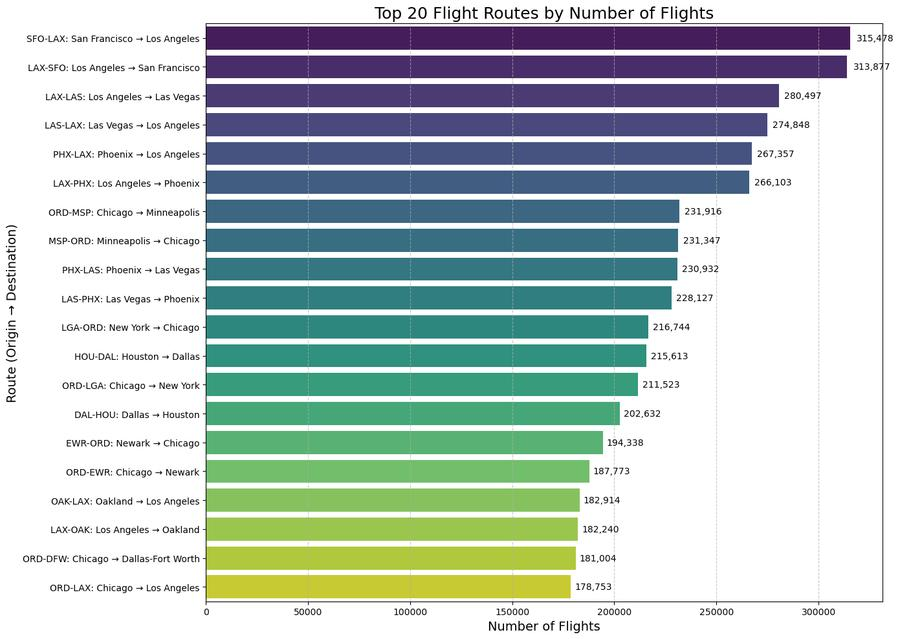

In [8]:
# Create a horizontal bar chart for better readability
plt.figure(figsize=(14, 10))
bars = sns.barplot(
    x='Count',
    y='Route',
    hue='Route',  # Add this line - use Route as hue
    data=routes_df.nlargest(20, 'Count'),
    palette='viridis',
    legend=False   # Add this line - hide the legend
)

# Add city information to the y-axis labels
ytick_labels = []
for i, route in enumerate(routes_df.nlargest(20, 'Count')['Route']):
    row = routes_df[routes_df['Route'] == route].iloc[0]
    ytick_labels.append(f"{route}: {row['Origin_City']} → {row['Dest_City']}")
    
plt.yticks(range(20), ytick_labels)

# Add count values at the end of each bar
for i, v in enumerate(routes_df.nlargest(20, 'Count')['Count']):
    bars.text(v + (v * 0.01), i, f"{v:,}", va='center')

# Add title and labels
plt.title('Top 20 Flight Routes by Number of Flights', fontsize=18)
plt.xlabel('Number of Flights', fontsize=14)
plt.ylabel('Route (Origin → Destination)', fontsize=14)
plt.grid(axis='x', linestyle='--', alpha=0.7)

# Show the plot
plt.tight_layout()
plt.show()

<HOME>\AppData\Roaming\Python\Python312\site-packages\shapely\creation.py:218: RuntimeWarning: invalid value encountered in linestrings
  return lib.linestrings(coords, np.intc(handle_nan), out=out, **kwargs)


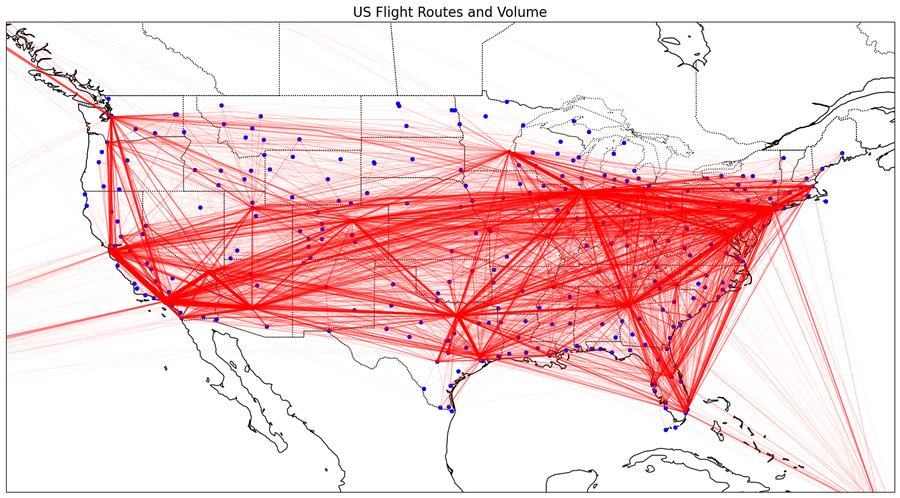

In [9]:
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import numpy as np

# Configurar o mapa
plt.figure(figsize=(15, 10))
ax = plt.axes(projection=ccrs.PlateCarree())
ax.add_feature(cfeature.COASTLINE)
ax.add_feature(cfeature.BORDERS, linestyle=':')
ax.add_feature(cfeature.STATES, linestyle=':')
ax.set_extent([-130, -65, 20, 50])  # Ajuste para os EUA

# Plotar os aeroportos
for _, row in routes_df.drop_duplicates(subset=['Origin']).iterrows():
    ax.plot(row['Origin_Long'], row['Origin_Lat'], 'bo', markersize=4, transform=ccrs.PlateCarree())
    
for _, row in routes_df.drop_duplicates(subset=['Dest']).iterrows():
    ax.plot(row['Dest_Long'], row['Dest_Lat'], 'bo', markersize=4, transform=ccrs.PlateCarree())

# Plotar as conexões com espessura proporcional ao número de voos
max_count = routes_df['Count'].max()
for _, row in routes_df.iterrows():
    if row['Count'] > 0:  # Apenas plotar rotas com voos
        # Normalizar a espessura da linha
        linewidth = 0.1 + (row['Count'] / max_count) * 5  # Ajuste a escala conforme necessário
        
        # Usar uma cor mais forte para rotas com mais voos
        alpha = min(0.2 + (row['Count'] / max_count) * 0.8, 1.0)
        
        # Desenhar a linha
        plt.plot([row['Origin_Long'], row['Dest_Long']], 
                 [row['Origin_Lat'], row['Dest_Lat']], 
                 'r-', linewidth=linewidth, alpha=alpha, 
                 transform=ccrs.Geodetic())

plt.title('US Flight Routes and Volume', fontsize=16)
plt.tight_layout()
plt.show()

## Preprocessing Crashes

In [10]:
def parse_coordinates(coord_str):
    """Converte uma string de coordenadas para uma tupla (lat, lon)."""
    if pd.isna(coord_str):
        return None
    try:
        # Se já for uma tupla, retorna diretamente
        if isinstance(coord_str, tuple):
            return coord_str
        
        # Remove parênteses e divide pelos valores
        clean_str = str(coord_str).replace('(', '').replace(')', '')
        if ',' in clean_str:
            lat, lon = map(float, clean_str.split(','))
            return (lat, lon)
    except Exception as e:
        print(f"Erro ao processar coordenadas '{coord_str}': {str(e)}")
    return None

def parse_route_waypoints(route, location_dict):
    """
    Extrai todos os pontos da rota e retorna suas coordenadas.
    Retorna uma lista de coordenadas para desenhar a rota completa.
    """
    if pd.isna(route) or route == "?":
        return None
    
    # Remove aspas e limpa
    route = str(route).replace('"', '').strip()
    
    # Separa pontos da rota pelo hífen
    waypoints = [point.strip() for point in route.split('-')]
    waypoints = [wp for wp in waypoints if wp]
    
    if len(waypoints) < 2:
        return None
    
    # Obtém coordenadas para cada ponto da rota
    waypoint_coords = []
    for point in waypoints:
        coords = location_dict.get(point)
        if coords:
            coords = parse_coordinates(coords)
            if coords:
                waypoint_coords.append(coords)
    
    # Retorna apenas se tiver pelo menos dois pontos para formar uma rota
    if len(waypoint_coords) >= 2:
        return waypoint_coords
    
    return None

def extract_number(fatalities_str):
    """Extrai o número de fatalidades da string."""
    if pd.isna(fatalities_str):
        return 0
    
    # Usa regex para extrair o número antes do parêntese
    match = re.search(r'(\d+)', str(fatalities_str))
    if match:
        return int(match.group(1))
    return 0

In [11]:
# Carrega os dados dos acidentes
print(f"Carregando dados de acidentes de {ACCIDENT_DATA_FILE}...")
crashes_df = pd.read_csv(ACCIDENT_DATA_FILE)
crashes_df = crashes_df.replace('?', np.nan).infer_objects(copy=False)
print(f"Carregados {len(crashes_df)} registros de acidentes")

# Carrega o arquivo de coordenadas
print(f"Carregando coordenadas de {COORDINATES_FILE}...")
coords_df = pd.read_csv(COORDINATES_FILE)
print(f"Carregadas {len(coords_df)} localizações com coordenadas")

# Cria um dicionário de localização -> coordenadas
location_dict = {}
for _, row in coords_df.iterrows():
    location_dict[row['Location']] = row['Coordinates']

# Adiciona coordenadas de acidentes ao dataframe principal
print("Combinando dados de acidentes com coordenadas...")
crashes_df['Coordinates'] = crashes_df['Location'].map(location_dict).apply(parse_coordinates)

# Extrai número de fatalidades como inteiro
crashes_df['Fatalities_Count'] = crashes_df['Fatalities'].apply(extract_number)

# Processa as rotas para obter coordenadas
print("Processando rotas de voo...")
routes_data = []

for i, row in crashes_df.iterrows():
    if pd.notna(row['Route']):
        route_waypoints = parse_route_waypoints(row['Route'], location_dict)
        routes_data.append({
            'index': i,
            'route_text': row['Route'],
            'waypoints': route_waypoints
        })

print(f"Processadas {len(routes_data)} rotas")
print(f"Acidentes com coordenadas: {crashes_df['Coordinates'].notna().sum()} de {len(crashes_df)}")
print(f"Rotas com coordenadas válidas: {sum(1 for r in routes_data if r['waypoints'] is not None)}")

Carregando dados de acidentes de data\crashes_data\plane_crash_data_backup.csv...
Carregados 5060 registros de acidentes
Carregando coordenadas de data\crashes_data\coordinates_cache.csv...
Carregadas 7680 localizações com coordenadas


<HOME>\AppData\Local\Temp\ipykernel_21500\3869098260.py:4: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  crashes_df = crashes_df.replace('?', np.nan).infer_objects(copy=False)


Combinando dados de acidentes com coordenadas...
Processando rotas de voo...
Processadas 4295 rotas
Acidentes com coordenadas: 4754 de 5060
Rotas com coordenadas válidas: 3816


In [12]:
# Inicializa o mapa centrado em coordenadas globais
print("Criando mapa...")
accident_map = folium.Map(location=[30, 0], zoom_start=2, tiles='CartoDB positron')

# Adiciona cluster de marcadores para os acidentes
marker_cluster = MarkerCluster(name="Acidentes").add_to(accident_map)

# Contador de acidentes processados
accidents_added = 0

for i, row in crashes_df.iterrows():
    if pd.notna(row['Coordinates']) and row['Coordinates'] is not None:
        try:
            lat, lon = row['Coordinates']
            
            # Prepara o texto do popup
            date_str = row['Date'] if pd.notna(row['Date']) else "Data desconhecida"
            location_str = row['Location'] if pd.notna(row['Location']) else "Local desconhecido"
            operator_str = row['Operator'] if pd.notna(row['Operator']) else "Operador desconhecido"
            fatalities_str = row['Fatalities'] if pd.notna(row['Fatalities']) else "Fatalidades desconhecidas"
            summary_str = row['Summary'] if pd.notna(row['Summary']) else "Sem resumo disponível"
            
            popup_text = f"""
            <b>Data:</b> {date_str}<br>
            <b>Local:</b> {location_str}<br>
            <b>Operador:</b> {operator_str}<br>
            <b>Fatalidades:</b> {fatalities_str}<br>
            <b>Resumo:</b> {str(summary_str)[:200]}{"..." if len(str(summary_str)) > 200 else ""}
            """
            
            # Adiciona marcador ao cluster - TODOS em VERMELHO para locais de acidentes
            folium.Marker(
                location=[lat, lon],
                popup=folium.Popup(popup_text, max_width=300),
                icon=folium.Icon(color='red', icon='plane', prefix='fa')
            ).add_to(marker_cluster)
            
            accidents_added += 1
        except Exception as e:
            print(f"Erro ao processar acidente #{i}: {str(e)}")
            continue

# Adiciona rotas ao mapa
print("Adicionando rotas...")
route_layer = folium.FeatureGroup(name="Rotas de Voo")
routes_added = 0

for route_data in routes_data:
    if route_data['waypoints']:
        try:
            # Cria uma polilinha que conecta todos os pontos da rota
            folium.PolyLine(
                locations=route_data['waypoints'],
                color='blue',
                weight=2,
                opacity=0.7,
                popup=f"Rota: {route_data['route_text']}"
            ).add_to(route_layer)
            
            # Adiciona marcadores para os pontos de origem e escalas (exceto o destino final que já é marcado como acidente)
            for i, waypoint in enumerate(route_data['waypoints'][:-1]):
                point_type = "Origem" if i == 0 else "Escala"
                folium.CircleMarker(
                    location=waypoint,
                    radius=5,
                    color='green',
                    fill=True,
                    fill_color='green',
                    fill_opacity=0.7,
                    popup=f"{point_type}: {route_data['route_text'].split('-')[i].strip()}"
                ).add_to(route_layer)
            
            routes_added += 1
        except Exception as e:
            print(f"Erro ao processar rota: {str(e)}")
            continue

route_layer.add_to(accident_map)

# Adiciona controle de camadas
folium.LayerControl().add_to(accident_map)

# Adiciona legenda personalizada
legend_html = '''
<div style="position: fixed; bottom: 50px; left: 50px; z-index: 1000; background-color: white; 
            padding: 10px; border: 2px solid grey; border-radius: 5px">
    <h4>Legenda</h4>
    <p><i class="fa fa-plane fa-1x" style="color:red"></i> Local do Acidente</p>
    <p><span style="background-color: green; height: 10px; width: 10px; border-radius: 50%; display: inline-block"></span> Origem/Escala</p>
    <p><span style="background-color: blue; height: 2px; width: 50px; display: inline-block"></span> Rota do Voo</p>
</div>
'''
accident_map.get_root().html.add_child(folium.Element(legend_html))

# Exibe estatísticas finais
print(f"Total de acidentes adicionados: {accidents_added}")
print(f"Total de rotas adicionadas: {routes_added}")



# Exibe o mapa no notebook
accident_map

Criando mapa...
Adicionando rotas...
Total de acidentes adicionados: 4754
Total de rotas adicionadas: 3816


[interactive output removed for repository size; re-run this cell to regenerate it]

In [13]:
from folium.plugins import HeatMap

# Criação de um mapa separado apenas para o heatmap
heatmap_only = folium.Map(location=[30, 0], zoom_start=2, tiles='CartoDB positron')

# Dados simplificados para o heatmap
heat_data = []
for i, row in crashes_df.iterrows():
    if pd.notna(row['Coordinates']) and row['Coordinates'] is not None:
        try:
            lat, lon = row['Coordinates']
            heat_data.append([lat, lon])
        except:
            continue

# Adicionar heatmap diretamente ao mapa
HeatMap(heat_data).add_to(heatmap_only)

# Adicionar título ao mapa
title_html = '''
<h3 align="center" style="font-size:16px"><b>Mapa de Calor - Concentração de Acidentes Aéreos</b></h3>
'''
heatmap_only.get_root().html.add_child(folium.Element(title_html))

# Exibir o mapa de calor
print(f"Mapa de calor criado com {len(heat_data)} pontos")
heatmap_only

Mapa de calor criado com 4754 pontos


In [14]:
import pandas as pd
import plotly.express as px


# Dicionário para mapear local -> coordenadas
location_dict = dict(zip(coords_df["Location"], coords_df["Coordinates"]))

# Converte Coordinates de string "(lat, lon)" para tupla de floats
crashes_df["Coordinates"] = (
    crashes_df["Location"]
    .map(location_dict)
    .str.strip("()")
    .str.split(",", expand=True)
    .astype(float)
    .apply(tuple, axis=1)
)

# Extrai data e ano
crashes_df["Date"] = pd.to_datetime(crashes_df["Date"], errors="coerce")
crashes_df = crashes_df.dropna(subset=["Coordinates", "Date"])
crashes_df[["lat", "lon"]] = pd.DataFrame(crashes_df["Coordinates"].tolist(), index=crashes_df.index)
crashes_df["Year"] = crashes_df["Date"].dt.year

crashes_df["Fatalities_Count"] = (
    crashes_df["Fatalities"]
      .str.extract(r"(\d+)")
      .astype(float)
)

# Agora podes limpar NaNs nessa coluna:
crashes_df["Fatalities_Count"] = crashes_df["Fatalities_Count"].fillna(0).astype(int)

fig = px.scatter_geo(
    crashes_df,
    lat="lat",
    lon="lon",
    color="Fatalities_Count",
    size="Fatalities_Count",
    animation_frame="Year",
    projection="natural earth",
    title="Acidentes Aéreos Globais por Ano",
    hover_name="Location",
    size_max=30
)
fig.update_layout(
    width=1000,
    height=600,
    margin=dict(l=20, r=20, t=50, b=20)
)
fig.show()


Número de acidentes entre 1987-2008: 1295


<HOME>\AppData\Roaming\Python\Python312\site-packages\shapely\creation.py:218: RuntimeWarning:

invalid value encountered in linestrings



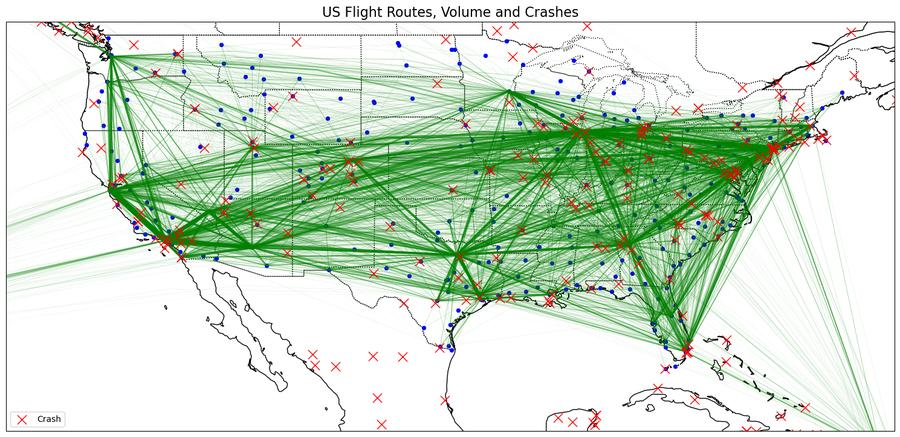

In [15]:
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import numpy as np

# Filtrar crashes apenas para o período entre 1987 e 2008
filtered_crashes_df = crashes_df[(crashes_df['Year'] >= 1987) & (crashes_df['Year'] <= 2008)]
print(f"\nNúmero de acidentes entre 1987-2008: {len(filtered_crashes_df)}")

# Configurar o mapa
# Extrai as coordenadas dos crashes
crash_coords = filtered_crashes_df['Coordinates'].dropna().tolist()
crash_lats   = [lat for lat, lon in crash_coords]
crash_lons   = [lon for lat, lon in crash_coords]

# Configurar a figura e o eixo Cartopy
fig = plt.figure(figsize=(15, 10))
ax  = fig.add_subplot(1, 1, 1, projection=ccrs.PlateCarree())
ax.add_feature(cfeature.COASTLINE)
ax.add_feature(cfeature.BORDERS,   linestyle=':')
ax.add_feature(cfeature.STATES,    linestyle=':')
ax.set_extent([-130, -65, 20, 50], ccrs.PlateCarree())

# 1) Plotar aeroportos de Origem e Destino
for _, row in routes_df.drop_duplicates(subset=['Origin']).iterrows():
    ax.plot(row['Origin_Long'], row['Origin_Lat'],
            'bo', markersize=4, transform=ccrs.PlateCarree())
for _, row in routes_df.drop_duplicates(subset=['Dest']).iterrows():
    ax.plot(row['Dest_Long'], row['Dest_Lat'],
            'bo', markersize=4, transform=ccrs.PlateCarree())

# 2) Plotar as rotas (linhas) com espessura proporcional ao nº de voos
max_count = routes_df['Count'].max()
for _, row in routes_df.iterrows():
    lw    = 0.1 + (row['Count'] / max_count) * 5
    alpha = min(0.2 + (row['Count'] / max_count) * 0.8, 1.0)
    ax.plot([row['Origin_Long'], row['Dest_Long']],
            [row['Origin_Lat'], row['Dest_Lat']],
            '-', color='green', linewidth=lw, alpha=alpha,
            transform=ccrs.Geodetic())

# 3) Plotar os crashes como marcadores “×” pretos
ax.scatter(
    crash_lons,
    crash_lats,
    transform=ccrs.PlateCarree(),
    marker='x',
    s=120,             # área do marcador: fica bem maior
    linewidths=1,      # traço mais espesso
    color='red',
    zorder=5,          # desenha por cima das linhas vermelhas
    label='Crash'
)

# 4) Legenda e título
ax.legend(loc='lower left')
plt.title('US Flight Routes, Volume and Crashes', fontsize=16)
plt.tight_layout()
plt.show()


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from matplotlib.colors import LogNorm, Normalize
from scipy.stats import gaussian_kde
from shapely.geometry import LineString, Point
import pandas as pd

filtered_df = filtered_crashes_df.copy()

# Definir o grid de análise para os EUA
grid_size = 100  # Controla a resolução da análise
lon_min, lon_max = -130, -65
lat_min, lat_max = 24, 50

# Criar uma função para contar rotas que atravessam cada célula
def count_routes_and_crashes_in_grid():
    # Criar grade para os EUA
    lon_bins = np.linspace(lon_min, lon_max, grid_size)
    lat_bins = np.linspace(lat_min, lat_max, grid_size)
    
    # Inicializar matrizes para contagem
    route_counts = np.zeros((len(lat_bins)-1, len(lon_bins)-1))
    crash_counts = np.zeros((len(lat_bins)-1, len(lon_bins)-1))
    
    # Transformar crashes em pontos do grid
    crash_points = []
    for _, crash in filtered_df.iterrows():
        if pd.notna(crash['lat']) and pd.notna(crash['lon']):
            # Encontrar em qual célula do grid o acidente ocorreu
            lon_idx = np.digitize(crash['lon'], lon_bins) - 1
            lat_idx = np.digitize(crash['lat'], lat_bins) - 1
            
            # Verificar se está dentro dos limites
            if (0 <= lon_idx < len(lon_bins)-1) and (0 <= lat_idx < len(lat_bins)-1):
                crash_counts[lat_idx, lon_idx] += 1
    
    # Processar cada rota
    for _, route in valid_routes_df.iterrows():
        # Criar uma linha entre origem e destino
        origin = (route['Origin_Long'], route['Origin_Lat'])
        dest = (route['Dest_Long'], route['Dest_Lat'])
        
        # Pular rotas inválidas
        if any(np.isnan(p) for p in origin + dest):
            continue
            
        # Gerar pontos intermédios ao longo da rota
        num_points = 50  # Ajustar conforme necessário
        lons = np.linspace(origin[0], dest[0], num_points)
        lats = np.linspace(origin[1], dest[1], num_points)
        
        # Criar um conjunto para rastrear células já contadas para esta rota
        counted_cells = set()
        
        # Contar a rota em cada célula que ela atravessa
        for lon, lat in zip(lons, lats):
            if lon_min <= lon <= lon_max and lat_min <= lat <= lat_max:
                lon_idx = np.digitize(lon, lon_bins) - 1
                lat_idx = np.digitize(lat, lat_bins) - 1
                
                cell_key = (lat_idx, lon_idx)
                if cell_key not in counted_cells and (0 <= lon_idx < len(lon_bins)-1) and (0 <= lat_idx < len(lat_bins)-1):
                    route_counts[lat_idx, lon_idx] += route['Count']  # Usar o número real de voos
                    counted_cells.add(cell_key)
    
    return route_counts, crash_counts, lon_bins, lat_bins

# Calcular as contagens
print("Calculando densidade de rotas e acidentes por região...")
route_counts, crash_counts, lon_bins, lat_bins = count_routes_and_crashes_in_grid()

# Calcular o rácio (acidentes por rota)
# Adicionar um pequeno valor para evitar divisão por zero
epsilon = 0.1
ratio = np.zeros_like(route_counts)
for i in range(route_counts.shape[0]):
    for j in range(route_counts.shape[1]):
        if route_counts[i, j] > 0:
            # Calcular o rácio: acidentes por 1000 voos
            ratio[i, j] = (crash_counts[i, j] / route_counts[i, j]) * 1000
        else:
            ratio[i, j] = np.nan  # Sem rotas, sem rácio

# Criar a figura e o eixo
fig = plt.figure(figsize=(16, 10))
ax = plt.axes(projection=ccrs.AlbersEqualArea(central_longitude=-97, central_latitude=38))

# Limitar para os EUA
ax.set_extent([lon_min, lon_max, lat_min, lat_max], crs=ccrs.PlateCarree())

# Adicionar características geográficas
ax.add_feature(cfeature.COASTLINE, linewidth=0.5)
ax.add_feature(cfeature.BORDERS, linestyle=':', linewidth=0.5)
ax.add_feature(cfeature.STATES, linestyle=':', linewidth=0.5)
ax.add_feature(cfeature.LAND, facecolor='lightgray', alpha=0.3)
ax.add_feature(cfeature.OCEAN, facecolor='lightblue', alpha=0.3)

# Criar malha para o mapa de calor
lons, lats = np.meshgrid(lon_bins[:-1] + np.diff(lon_bins)/2, 
                         lat_bins[:-1] + np.diff(lat_bins)/2)

# Criar máscara para valores não-nulos
mask = ~np.isnan(ratio)

# Plotar o mapa de calor com uma escala de cores personalizada
cmap = plt.cm.coolwarm
vmin = np.nanmin(ratio[ratio > 0])  # Valor mínimo positivo
vmax = np.nanpercentile(ratio[ratio > 0], 95)  # 95º percentil para evitar outliers

# Aplicar transformação logarítmica para destacar diferenças
im = ax.pcolormesh(lons, lats, ratio, transform=ccrs.PlateCarree(),
                   cmap=cmap, norm=LogNorm(vmin=max(vmin, 0.01), vmax=vmax),
                   alpha=0.7)

# Adicionar barra de cores e título
cbar = plt.colorbar(im, ax=ax, shrink=0.7, pad=0.05)
cbar.set_label('Acidentes por 1000 Voos', rotation=270, labelpad=20, fontsize=12)

# Adicionar estatísticas ao título
total_routes = np.sum(route_counts)
total_crashes = np.sum(crash_counts)
plt.title(f'Rácio entre Acidentes e Densidade de Rotas nos EUA (1987-2008)\n'
          f'Total: {int(total_crashes)} acidentes em {int(total_routes/1000)}K voos', 
          fontsize=14)

# Adicionar texto explicativo
plt.figtext(0.15, 0.02, 
           "Áreas em vermelho indicam regiões com maior risco relativo (mais acidentes por voo).\n"
           "Áreas em branco representam regiões sem rotas registradas ou sem acidentes.",
           wrap=True, fontsize=10)

# Adicionar fonte de dados
plt.figtext(0.85, 0.02, "Fonte: Dados de acidentes aéreos\ne rotas aéreas (1987-2008)",
           ha="right", fontsize=8)

plt.tight_layout()
plt.show()

print("Análise concluída.")

Calculando densidade de rotas e acidentes por região...


NameError: name 'filtered_df' is not defined

In [18]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from collections import Counter

# Analisar rotas mais perigosas do dataset de acidentes
print("Analisando dados para gráfico de rotas mais perigosas...")

# Palavras a excluir das rotas
excluded_terms = ["demonstration", "training", "test flight", "sightseeing", "test"]

# Contar acidentes por rota
route_crash_counts = Counter()
route_fatalities = {}

# Analisar todas as rotas nos dados de acidentes
for i, row in df.iterrows():
    if pd.notna(row['Route']) and row['Route'] != '?':
        route = str(row['Route']).strip().lower()
        
        # Verificar se a rota contém termos a serem excluídos
        if any(term in route for term in excluded_terms):
            continue
            
        # Usar a versão original (não minúscula) para exibição
        original_route = str(row['Route']).strip()
        
        # Incrementar contador para esta rota
        route_crash_counts[original_route] += 1
        
        # Rastrear fatalidades
        if original_route not in route_fatalities:
            route_fatalities[original_route] = 0
        
        if pd.notna(row['Fatalities_Count']):
            route_fatalities[original_route] += row['Fatalities_Count']

# Obter as 15 rotas mais perigosas
most_dangerous_routes = route_crash_counts.most_common(15)

if not most_dangerous_routes:
    print("Não foram encontradas rotas válidas com múltiplos acidentes.")
else:
    # Preparar dados para o gráfico
    routes = [r[0] for r in most_dangerous_routes]
    crash_counts = [r[1] for r in most_dangerous_routes]
    fatalities = [route_fatalities.get(r, 0) for r in routes]
    
    # Simplificar nomes de rotas muito longas
    display_routes = []
    for route in routes:
        if len(route) > 25:
            parts = route.split('-')
            if len(parts) > 2:
                route = f"{parts[0]}-...-{parts[-1]}"
        display_routes.append(route)
    
    # Inverter a ordem para que a rota mais perigosa fique no topo
    display_routes.reverse()
    crash_counts.reverse()
    fatalities.reverse()
    
    # Criar figura com tamanho adequado
    plt.figure(figsize=(12, 10))
    
    # Criar gráfico de barras horizontal
    y_pos = np.arange(len(display_routes))
    bars = plt.barh(y_pos, crash_counts, color='darkred')
    
    # Configurar eixos e rótulos
    plt.yticks(y_pos, display_routes)
    plt.xlabel('Número de Acidentes')
    plt.title('Rotas Comerciais Mais Perigosas do Mundo\n(excluindo voos de demonstração, treinamento e teste)', fontsize=14)
    
    # Adicionar valor numérico ao lado de cada barra
    for i, v in enumerate(crash_counts):
        plt.text(v + 0.1, i, str(v), va='center')
        
        # Adicionar informação de fatalidades
        if v > 2:  # Só adiciona em barras com espaço suficiente
            plt.text(v/2, i, f"{fatalities[i]} mortes", ha='center', va='center', 
                     color='white', fontweight='bold')
    
    # Adicionar grid no eixo x para melhor legibilidade
    plt.grid(axis='x', linestyle='--', alpha=0.3)
    
    # Adicionar anotação de fonte
    plt.figtext(0.5, 0.01, 
                "Fonte: Dataset histórico de acidentes aéreos globais\nData: 2025-05-11",
                ha="center", fontsize=10)
    
    # Ajustar layout
    plt.tight_layout()
    
    # Mostrar o gráfico
    plt.show()
    
    # Imprimir estatísticas adicionais
    print(f"\nEstatísticas das {len(most_dangerous_routes)} rotas comerciais mais perigosas:")
    print(f"Total de acidentes: {sum(crash_counts)}")
    print(f"Total de fatalidades: {sum(fatalities)}")

Analisando dados para gráfico de rotas mais perigosas...


NameError: name 'df' is not defined

In [ ]:
import pandas as pd
import numpy as np
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import ipywidgets as widgets
from IPython.display import display, clear_output

# Preparar os dados para análise
print("Preparando dados para análise interativa de acidentes aéreos por companhia e tipo de aeronave...")

# Limpeza de dados
analysis_df = crashes_df.copy()
analysis_df['Operator'] = analysis_df['Operator'].fillna('Desconhecido')
analysis_df['AC Type'] = analysis_df['AC Type'].fillna('Desconhecido')

# Remover linhas onde Operator ou AC Type são '?'
analysis_df = analysis_df[~((analysis_df['Operator'] == '?') | (analysis_df['AC Type'] == '?'))]

# Converter data para datetime se necessário
if not pd.api.types.is_datetime64_any_dtype(analysis_df['Date']):
    analysis_df['Date'] = pd.to_datetime(analysis_df['Date'], errors='coerce')
analysis_df['Year'] = analysis_df['Date'].dt.year

# Extrair os top operadores e aeronaves por número de acidentes
top_operators = analysis_df['Operator'].value_counts().head(30).index.tolist()
top_aircraft = analysis_df['AC Type'].value_counts().head(30).index.tolist()

# Criar contagens para as diferentes combinações
operator_aircraft_counts = analysis_df.groupby(['Operator', 'AC Type']).size().reset_index(name='accident_count')

# Criar função para atualizar gráficos
def update_charts(selected_operators=None, selected_aircraft=None):
    # Filtrar dados
    filtered_df = analysis_df.copy()
    
    if selected_operators and len(selected_operators) > 0:
        filtered_df = filtered_df[filtered_df['Operator'].isin(selected_operators)]
    
    if selected_aircraft and len(selected_aircraft) > 0:
        filtered_df = filtered_df[filtered_df['AC Type'].isin(selected_aircraft)]
    
    # Criar figura com subplots
    fig = make_subplots(
        rows=2, cols=2,
        specs=[[{"type": "bar"}, {"type": "pie"}], 
               [{"type": "bar"}, {"type": "indicator"}]],
        subplot_titles=(
            "Tipos de Aeronave com Mais Acidentes", 
            "Proporção de Acidentes por Companhia",
            "Companhias com Mais Acidentes", 
            "Total de Acidentes"
        ),
        column_widths=[0.6, 0.4],
        row_heights=[0.5, 0.5],
        vertical_spacing=0.1,
        horizontal_spacing=0.05
    )
    
    # Gráfico 1: Tipos de aeronave com mais acidentes
    aircraft_counts = filtered_df['AC Type'].value_counts().reset_index()
    aircraft_counts.columns = ['AC Type', 'count']
    aircraft_counts = aircraft_counts.sort_values('count', ascending=False).head(10)
    
    fig.add_trace(
        go.Bar(
            x=aircraft_counts['count'],
            y=aircraft_counts['AC Type'],
            orientation='h',
            marker=dict(color='firebrick'),
            name='Acidentes por Aeronave'
        ),
        row=1, col=1
    )
    
    # Gráfico 2: Proporção de acidentes por companhia (pizza)
    operator_counts = filtered_df['Operator'].value_counts().reset_index()
    operator_counts.columns = ['Operator', 'count']
    operator_counts = operator_counts.sort_values('count', ascending=False).head(8)
    
    fig.add_trace(
        go.Pie(
            labels=operator_counts['Operator'],
            values=operator_counts['count'],
            hole=0.4,
            textinfo='percent+label',
            insidetextorientation='radial',
            marker=dict(colors=px.colors.sequential.Reds)
        ),
        row=1, col=2
    )
    
    # Gráfico 3: Companhias com mais acidentes
    operator_counts_bar = operator_counts.sort_values('count', ascending=False).head(10)
    
    fig.add_trace(
        go.Bar(
            x=operator_counts_bar['count'],
            y=operator_counts_bar['Operator'],
            orientation='h',
            marker=dict(color='darkblue'),
            name='Acidentes por Companhia'
        ),
        row=2, col=1
    )
    
    # Gráfico 4: Indicador de total de acidentes
    total_accidents = len(filtered_df)
    total_fatalities = filtered_df['Fatalities_Count'].sum()
    
    fig.add_trace(
        go.Indicator(
            mode="number+delta",
            value=total_accidents,
            title={
                "text": f"<span style='font-size:0.8em'>Total de Acidentes<br><span style='font-size:0.8em;color:gray'>{total_fatalities} Fatalidades</span></span>"
            },
            delta={'reference': len(analysis_df), 'relative': True, 'position': "bottom"},
            domain={'row': 1, 'column': 1}
        ),
        row=2, col=2
    )
    
    # Atualizar layout
    title_text = "Análise de Acidentes Aéreos"
    if selected_operators and len(selected_operators) > 0:
        title_text += f" - Companhias: {', '.join(selected_operators)}"
    if selected_aircraft and len(selected_aircraft) > 0:
        title_text += f" - Aeronaves: {', '.join(selected_aircraft)}"
        
    fig.update_layout(
        title_text=title_text,
        title_x=0.5,
        height=800,
        width=1200,
        showlegend=False,
        template="plotly_white"
    )
    
    # Formatação dos gráficos de barras
    fig.update_xaxes(title_text="Número de Acidentes", row=1, col=1)
    fig.update_yaxes(title_text="Tipo de Aeronave", row=1, col=1)
    fig.update_xaxes(title_text="Número de Acidentes", row=2, col=1)
    fig.update_yaxes(title_text="Companhia Aérea", row=2, col=1)
    
    return fig, filtered_df

# Criar widgets interativos
operator_dropdown = widgets.SelectMultiple(
    options=top_operators,
    value=[],
    description='Companhias:',
    layout=widgets.Layout(width='50%', height='200px')
)

aircraft_dropdown = widgets.SelectMultiple(
    options=top_aircraft,
    value=[],
    description='Aeronaves:',
    layout=widgets.Layout(width='50%', height='200px')
)

clear_button = widgets.Button(
    description='Limpar Seleções',
    button_style='danger', 
    icon='trash'
)

# Função para manipular o botão de limpar
def on_clear_button_clicked(b):
    operator_dropdown.value = []
    aircraft_dropdown.value = []

clear_button.on_click(on_clear_button_clicked)

# Widgets para exibir estatísticas
stats_output = widgets.Output()

# Função para atualizar estatísticas
def update_stats(df):
    with stats_output:
        clear_output()
        
        # Extrair estatísticas interessantes
        total_accidents = len(df)
        total_fatalities = df['Fatalities_Count'].sum()
        avg_fatalities = total_fatalities / total_accidents if total_accidents > 0 else 0
        
        # Década com mais acidentes
        decade_counts = df['Year'].dropna().apply(lambda x: (x // 10) * 10).value_counts().sort_index()
        worst_decade = decade_counts.idxmax() if not decade_counts.empty else 'N/A'
        worst_decade_count = decade_counts.max() if not decade_counts.empty else 0
        
        # Anos com mais acidentes
        year_counts = df['Year'].value_counts().sort_index()
        worst_years = year_counts.nlargest(3)
        
        # Criar output formatado
        print(f"## Estatísticas dos Acidentes Selecionados")
        print(f"\nTotal de acidentes: {total_accidents}")
        print(f"Total de fatalidades: {int(total_fatalities)}")
        print(f"Média de fatalidades por acidente: {avg_fatalities:.1f}")
        
        print(f"\n### Distribuição Temporal")
        print(f"Década com mais acidentes: {worst_decade}s ({worst_decade_count} acidentes)")
        
        print("\n### Anos com mais acidentes:")
        for year, count in worst_years.items():
            print(f"- {int(year)}: {count} acidentes")
        
        # Causas mais comuns (se disponível no dataset)
        if 'Summary' in df.columns:
            print("\n### Principais detalhes dos acidentes:")
            for i, (idx, row) in enumerate(df.sort_values('Fatalities_Count', ascending=False).head(3).iterrows()):
                print(f"\n{i+1}. **{row['Date'].strftime('%Y-%m-%d') if pd.notna(row['Date']) else 'Data desconhecida'}** - "
                      f"{row['Operator']} ({row['AC Type']})")
                print(f"   Local: {row['Location'] if pd.notna(row['Location']) else 'Desconhecido'}")
                print(f"   Fatalidades: {int(row['Fatalities_Count'])}")
                if pd.notna(row['Summary']):
                    print(f"   Resumo: {row['Summary'][:150]}...")

# Função para atualizar o output quando os widgets mudarem
output = widgets.Output()

def on_change(change):
    with output:
        clear_output(wait=True)
        fig, filtered_df = update_charts(
            selected_operators=operator_dropdown.value, 
            selected_aircraft=aircraft_dropdown.value
        )
        fig.show()
        update_stats(filtered_df)

operator_dropdown.observe(on_change, names='value')
aircraft_dropdown.observe(on_change, names='value')

# Mostrar os widgets e o gráfico inicial
print("Dashboard interativo de acidentes aéreos por companhia e tipo de aeronave")
display(widgets.HBox([
    widgets.VBox([widgets.Label('Selecione as companhias aéreas:'), operator_dropdown]),
    widgets.VBox([widgets.Label('Selecione os tipos de aeronave:'), aircraft_dropdown])
]))
display(clear_button)

# Mostrar o gráfico inicial
with output:
    fig, filtered_df = update_charts()
    fig.show()
    update_stats(filtered_df)

display(output)
display(stats_output)